<a href="https://colab.research.google.com/github/Parv-01/Kshitij_Sir_Repo_Check_IITP/blob/main/Re_Po_PDS_executability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Re-Po-PDS: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/Re-Po-PDS](https://github.com/Mishrakshitij/Re-Po-PDS)   
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'Re-Po-PDS'
COMMIT = '7fac6d625d2edb2b4f6648a4249e8fd413480f3e'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: 7fac6d625d2edb2b4f6648a4249e8fd413480f3e
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


### Compatibility with the repository requirements
The table checks installed versions against the base dependencies and optional dependency groups used by this experiment.

In [ ]:
import tomllib
from packaging.requirements import Requirement
from packaging.version import Version
import pandas as pd
from IPython.display import display
project_metadata = tomllib.loads((REPO_ROOT / 'pyproject.toml').read_text())['project']
assert Version(sys.version.split()[0]) in __import__('packaging.specifiers', fromlist=['SpecifierSet']).SpecifierSet(project_metadata['requires-python'])
extras = {
    'PACD': ['baselines', 'plots'], 'PADS': ['train', 'politeness', 'plots'],
    'RL-Emo-Per': ['train', 'figures'], 'PEPDS': ['train', 'plots'],
    'GenPADS': ['train', 'metrics', 'figures'], 'Po-Em-MHLCDS': ['plots'],
    'PAL': ['train', 'eval', 'plots'], 'e-THERAPIST': [],
    'Re-Po-PDS': ['train', 'plots'], 'ABLE': ['train', 'plots'], 'EDiSS': ['train', 'plots']
}[PROJECT]
specs = list(project_metadata.get('dependencies', []))
for extra in extras:
    specs += project_metadata.get('optional-dependencies', {}).get(extra, [])
dependency_rows = []
for spec in specs:
    requirement = Requirement(spec)
    if requirement.marker and not requirement.marker.evaluate():
        continue
    installed = metadata.version(requirement.name)
    compatible = Version(installed) in requirement.specifier
    dependency_rows.append({'requirement': spec, 'installed': installed, 'compatible': compatible})
assert dependency_rows and all(row['compatible'] for row in dependency_rows)
display(pd.DataFrame(dependency_rows))
(OUTPUT_DIR / 'environment_check.json').write_text(__import__('json').dumps({'python': sys.version.split()[0], 'checked_extras': extras, 'dependencies': dependency_rows}, indent=2))
print('PASS: Python and all dependencies declared for the tested paths are compatible.')


,requirement,installed,compatible
0,"torch>=2.2,<3",2.13.0+cu129,True
1,"transformers>=4.46,<6",4.57.6,True
2,"nltk>=3.9,<4",3.10.3,True
3,"matplotlib>=3.7,<4",3.10.7,True


PASS: Python and all dependencies declared for the tested paths are compatible.


# Re-Po-PDS: bounded executability study
This notebook checks the repository's supervised persuader language-model path using a small published dataset subset and a tiny Hugging Face GPT-2 checkpoint. The check covers loading, five optimizer updates, checkpoint serialization, checkpoint reload, and four held-out examples. It is an execution check rather than a reproduction of paper-level quality.

The classifier, PPO, resistance-gating, and politeness-transfer stages remain outside this bounded run.

In [ ]:
import gc
import hashlib
import json
import math
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

sys.path.insert(0, str(REPO_ROOT / "src"))
from repopds.data import load_dialogues, split_records, dialogue_examples
from repopds.models import load_model
from repopds.training import TrainConfig, train_supervised, evaluate_model
from repopds.inference import generate_response

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(2)
torch.manual_seed(42)
COMMIT = subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip()
print("Repository:", "https://github.com/Mishrakshitij/Re-Po-PDS")
print("Commit:", COMMIT)
print("Runtime:", DEVICE, "| PyTorch:", torch.__version__)

Repository: https://github.com/Mishrakshitij/Re-Po-PDS
Commit: 7fac6d625d2edb2b4f6648a4249e8fd413480f3e
Runtime: cuda | PyTorch: 2.13.0+cu129


## Dataset integrity and exploratory analysis
Counts, schemas, label distributions, and split isolation are checked against the committed release. Dialogue splits are made before selecting small training, validation, and test samples, so the held-out conversations do not enter training.

dialogue: 10,864 rows; splits {'train': 8833, 'validation': 971, 'test': 1060}
persuasion: 6,017 rows; splits {'train': 4879, 'validation': 558, 'test': 580}
resistance: 4,638 rows; splits {'train': 3795, 'validation': 399, 'test': 444}
politeness: 10,864 rows; splits {'train': 8833, 'validation': 971, 'test': 1060}
intensity: 8,302 rows; splits {'train': 6765, 'validation': 744, 'test': 793}
persuasive: 6,017 rows; splits {'train': 4879, 'validation': 558, 'test': 580}
transfer: 7,795 rows; splits {'train': 6340, 'validation': 701, 'test': 754}
wikipedia_requests: 4,353 rows
paranmt_filtered: 74,554 rows
Dataset schemas, labels, checksums, source references and shared partitions verified.



,file,rows,columns
0,datasets/auxiliary/paranmt_filtered.csv,74554,4
1,datasets/auxiliary/wikipedia_requests.csv,4353,4
2,datasets/p4g/dialogues.csv,10864,8
3,datasets/pop4g/intensity.csv,8302,5
4,datasets/pp4g/politeness.csv,10864,5
5,datasets/ptp4g/transfer.csv,7795,5
6,datasets/rp4g/resistance.csv,4638,5


,example_id,dialogue_id,utterance_id,turn,sentence_id,speaker,text,persuasion_label
0,20180719-210146_172_live:0,20180719-210146_172_live,0,0,0,persuader,Hello.,10
1,20180719-210146_172_live:1,20180719-210146_172_live,1,0,1,persuader,How are you?,10
2,20180719-210146_172_live:2,20180719-210146_172_live,2,0,2,persuadee,"I'm good, how are you doing?",
3,20180719-210146_172_live:3,20180719-210146_172_live,3,1,3,persuader,Very well.,10


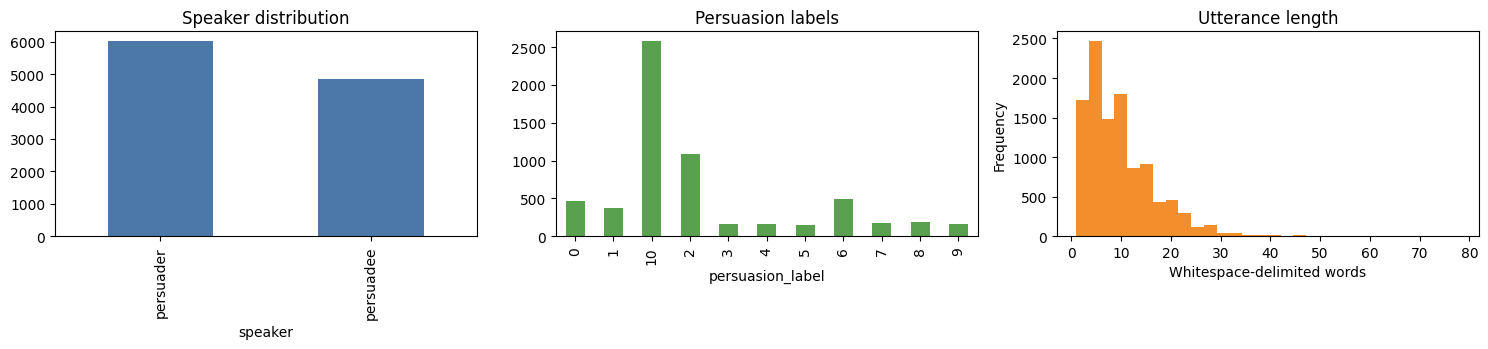

Dialogues: 300


In [ ]:
verification = subprocess.run([sys.executable, str(REPO_ROOT / "scripts/verify_dataset.py")],
                              cwd=REPO_ROOT, capture_output=True, text=True, check=True)
print(verification.stdout)
overview = []
for path in sorted((REPO_ROOT / "datasets").rglob("*.csv")):
    frame = pd.read_csv(path, keep_default_na=False)
    overview.append({"file": path.relative_to(REPO_ROOT).as_posix(), "rows": len(frame),
                     "columns": len(frame.columns)})
overview = pd.DataFrame(overview)
display(overview)
data = pd.read_csv(REPO_ROOT / "datasets/p4g/dialogues.csv", keep_default_na=False)
display(data.head(4))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
data["speaker"].value_counts().plot.bar(ax=axes[0], color="#4C78A8", title="Speaker distribution")
data.loc[data["persuasion_label"].astype(str).ne(""), "persuasion_label"].value_counts().sort_index().plot.bar(ax=axes[1], color="#59A14F", title="Persuasion labels")
data["text"].astype(str).str.split().str.len().plot.hist(ax=axes[2], bins=30, color="#F28E2B", title="Utterance length")
axes[2].set_xlabel("Whitespace-delimited words")
plt.tight_layout()
plt.show()
print("Dialogues:", data["dialogue_id"].nunique())

In [ ]:
source_splits = split_records(load_dialogues(REPO_ROOT / "datasets"), "dialogue", seed=10)
all_examples = {name: dialogue_examples(rows, role="persuader") for name, rows in source_splits.items()}
train_records = all_examples["train"][:10]
validation_records = all_examples["validation"][:4]
test_records = all_examples["test"][:4]
assert [len(train_records), len(validation_records), len(test_records)] == [10, 4, 4]
train_ids = {r["dialogue_id"] for r in train_records}
validation_ids = {r["dialogue_id"] for r in validation_records}
test_ids = {r["dialogue_id"] for r in test_records}
assert not (train_ids & validation_ids or train_ids & test_ids or validation_ids & test_ids)
display(pd.DataFrame([{"split": name, "available_examples": len(all_examples[name]), "selected_examples": count}
                      for name, count in [("train", 10), ("validation", 4), ("test", 4)]]))
display(pd.DataFrame(train_records)[["example_id", "dialogue_id", "prompt", "response"]].head(4))
(OUTPUT_DIR / "subset.json").write_text(json.dumps({"train": train_records, "validation": validation_records, "test": test_records}, indent=2))

,split,available_examples,selected_examples
0,train,4879,10
1,validation,558,4
2,test,580,4


,example_id,dialogue_id,prompt,response
0,20180719-210146_172_live:0,20180719-210146_172_live,persuader:,Hello.
1,20180719-210146_172_live:1,20180719-210146_172_live,persuader: Hello.\npersuader:,How are you?
2,20180719-210146_172_live:3,20180719-210146_172_live,persuader: Hello.\npersuader: How are you?\npe...,Very well.
3,20180719-210146_172_live:4,20180719-210146_172_live,persuader: Hello.\npersuader: How are you?\npe...,I'm just up organizing info for my charity.


18454

## Native model loading and five-step training
The repository loader configures causal padding, and its training loop masks prompt tokens from the response loss. The same native loop selects and saves the checkpoint using the four validation examples. A change in learned parameters is checked independently of the loss value.

In [ ]:
model, tokenizer = load_model("lm", CAUSAL_MODEL)
model.config.repopds_role = "persuader"
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print("Hugging Face model:", CAUSAL_MODEL, "| Parameters:", f"{parameter_count:,}")
initial = {name: value.detach().cpu().clone() for name, value in model.named_parameters()}
configuration = TrainConfig(epochs=1, batch_size=2, max_steps=5, max_length=64,
                            learning_rate=5e-4, seed=10)
checkpoint = OUTPUT_DIR / "checkpoint"
history = train_supervised(model, tokenizer, train_records, validation_records,
                           "lm", checkpoint, configuration, device=DEVICE)
updates = history[-1]["steps"]
assert updates == 5
assert all(math.isfinite(record["train_loss"]) and math.isfinite(record["validation"]["loss"]) for record in history)
parameter_delta = sum(float((value.detach().cpu() - initial[name]).abs().sum()) for name, value in model.named_parameters())
assert parameter_delta > 0
assert (checkpoint / "config.json").is_file()
assert any(checkpoint.glob("*.safetensors"))
display(pd.DataFrame([{"optimizer_steps": updates, "train_loss": history[-1]["train_loss"],
                       "validation_loss": history[-1]["validation"]["loss"], "parameter_l1_change": parameter_delta}]))

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hugging Face model: sshleifer/tiny-gpt2 | Parameters: 102,714


{"epoch": 1, "steps": 5, "train_loss": 10.82330187629251, "validation": {"loss": 10.822352827265021, "examples": 4, "perplexity": 50128.892991807654, "target_tokens": 89}}


python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


,optimizer_steps,train_loss,validation_loss,parameter_l1_change
0,5,10.823302,10.822353,58.697293


## Checkpoint reload and four-example evaluation
Reloading uses the repository model loader. Parameter equality verifies serialization; native token-weighted evaluation and generation then use only the four held-out examples selected above. Tiny-model responses and perplexity are diagnostic outputs, not evidence of useful dialogue quality.

In [ ]:
reloaded, reloaded_tokenizer = load_model("lm", str(checkpoint))
max_reload_difference = max(float((value.detach().cpu() - reloaded.state_dict()[name].detach().cpu()).abs().max())
                            for name, value in model.state_dict().items())
assert max_reload_difference == 0
del model, initial
gc.collect()
metrics = evaluate_model(reloaded, reloaded_tokenizer, test_records, "lm", configuration, device=DEVICE)
assert metrics["examples"] == 4 and math.isfinite(metrics["loss"]) and math.isfinite(metrics["perplexity"])
predictions = [{"example_id": row["example_id"], "reference": row["response"],
                "prediction": generate_response(reloaded, reloaded_tokenizer, row["prompt"],
                    device=DEVICE, max_new_tokens=12, max_length=64, sample=False)} for row in test_records]
display(pd.DataFrame([metrics]))
display(pd.DataFrame(predictions))
result = {"project": "Re-Po-PDS", "status": "PASS", "scope": "native supervised persuader causal LM",
          "model": CAUSAL_MODEL, "commit": COMMIT, "parameters": parameter_count,
          "updates": updates, "counts": {"train": 10, "validation": 4, "evaluation": 4},
          "metrics": metrics, "training_history": history,
          "parameter_l1_change": parameter_delta, "reload_max_abs_difference": max_reload_difference,
          "dataset_integrity": "PASS", "dataset_rows": int(overview["rows"].sum()),
          "checkpoints": ["checkpoint"], "predictions": predictions,
          "limitations": ["Classifiers, PPO rewards, resistance gate, and politeness transfer are not exercised.", "Five-step tiny-model execution does not establish converged quality or reproduce paper results."]}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False))
print("PASS: dataset checks, native model load, five optimizer updates, save/reload, and four-example evaluation.")

,loss,examples,perplexity,target_tokens
0,10.819792,4,50000.699317,46


,example_id,reference,prediction
0,20180723-042344_940_live:0,How much money do you spend daily on extras li...,factors factors factors factors factors factor...
1,20180723-042344_940_live:2,About 1 dollar per day.,factors factors factors factors factors factor...
2,20180723-042344_940_live:3,Do you think that amount of money would make a...,stairs stairs stairs stairs stairs stairs stai...
3,20180723-042344_940_live:5,I agree.,factors factors factors factors factors factor...


PASS: dataset checks, native model load, five optimizer updates, save/reload, and four-example evaluation.


## Project summary

**Result: PASS for the tested smoke configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved and reloaded, and the evaluation covered **4 held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.